In [1]:
import tkinter as tk
from tkinter import filedialog
import pydicom
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft2, ifft2, fftshift
import cv2

In [2]:
def load_dicom_frames():
    root = tk.Tk()
    root.withdraw()
    file_path = filedialog.askopenfilename(title="Select DICOM File", filetypes=[("DICOM files", "*.dcm")])
    
    if not file_path:
        print("No file selected.")
        return None
    
    ds = pydicom.dcmread(file_path)
    
    if not hasattr(ds, 'PixelData') or not hasattr(ds, 'NumberOfFrames'):
        print("This is not a multi-frame DICOM.")
        return None

    frames = ds.pixel_array.astype(np.float16)
    print(f"Loaded {len(frames)} frames from: {file_path}")
    
    return frames

In [3]:
def preprocess_frame_for_logpolar(frame):
    # Convert to 8-bit and apply histogram equalization
    frame_8bit = cv2.normalize(frame, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    equalized = cv2.equalizeHist(frame_8bit)
    return equalized

In [4]:
def phase_correlation_log_polar(ref, tgt):
    ref = preprocess_frame_for_logpolar(ref)
    tgt = preprocess_frame_for_logpolar(tgt)

    sz = ref.shape
    center = (sz[1] // 2, sz[0] // 2)

    # Convert to log-polar space
    ref_lp = cv2.logPolar(ref, center, 40, cv2.INTER_LINEAR + cv2.WARP_FILL_OUTLIERS)
    tgt_lp = cv2.logPolar(tgt, center, 40, cv2.INTER_LINEAR + cv2.WARP_FILL_OUTLIERS)

    # Phase correlation on log-polar images
    shift, _ = cv2.phaseCorrelate(np.float32(ref_lp), np.float32(tgt_lp))
    return shift  # This includes rotation and scale components

In [5]:
def register_with_phase_correlation(reference, target):
    # Convert to float32 for FFT
    ref_f = reference.astype(np.float32)
    tgt_f = target.astype(np.float32)

    # Apply FFT
    F_ref = fft2(ref_f)
    F_tgt = fft2(tgt_f)

    # Cross power spectrum
    R = (F_ref * F_tgt.conj()) / np.abs(F_ref * F_tgt.conj())
    r = ifft2(R)
    shift = np.unravel_index(np.argmax(np.abs(r)), r.shape)

    # Convert to actual x/y shift
    shifts = np.array(shift, dtype=np.float32)
    shifts[shifts > reference.shape[0] // 2] -= reference.shape[0]

    # Apply shift in Fourier domain
    shifted = np.real(ifft2(F_tgt * np.exp(-2j * np.pi * (shifts[0] * np.fft.fftfreq(target.shape[0])[:, None] + shifts[1] * np.fft.fftfreq(target.shape[1])))))
    shifted = np.clip(shifted, 0, 65535).astype(np.uint16)

    return shifted, shifts

In [6]:
def visualize_phase_correlation(mask, live):
    F1, F2, corr = register_with_phase_correlation(mask, live)

    plt.figure(figsize=(16, 6))

    plt.subplot(2, 3, 1)
    plt.imshow(mask, cmap='gray')
    plt.title("Mask Frame")

    plt.subplot(2, 3, 2)
    plt.imshow(live, cmap='gray')
    plt.title("Live Frame")

    plt.subplot(2, 3, 3)
    plt.imshow(np.log1p(np.abs(fftshift(F1))), cmap='gray')
    plt.title("FFT (Mask)")

    plt.subplot(2, 3, 4)
    plt.imshow(np.log1p(np.abs(fftshift(F2))), cmap='gray')
    plt.title("FFT (Live)")

    plt.subplot(2, 3, 5)
    plt.imshow(corr, cmap='hot')
    plt.title("Phase Correlation Output")

    plt.tight_layout()
    plt.show()

In [7]:
def apply_dsa(mask_frame, live_frame):
    # Convert to float32 for precise subtraction
    mask = mask_frame.astype(np.float16)
    live = live_frame.astype(np.float16)

    # DSA subtraction
    dsa = live - mask*2 

    # Shift pixel values to make all values positive for display
    dsa_shifted = dsa - np.min(dsa)

    # Avoid divide-by-zero
    range_val = np.max(dsa_shifted)
    if range_val == 0:
        range_val = 0.5  

    # Normalize to 0–255
    dsa_normalized = (dsa_shifted / range_val)* 64.0

    # Convert to uint8 for display
    return dsa_normalized.astype(np.uint8)


def show_dsa_result(mask_frame, live_frame):
    dsa_image = apply_dsa(mask_frame, live_frame)
    
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 3, 1)
    plt.imshow(mask_frame, cmap='gray')
    plt.title("Mask Frame")

    plt.subplot(1, 3, 2)
    plt.imshow(live_frame, cmap='gray')
    plt.title("Live Frame")

    plt.subplot(1, 3, 3)
    plt.imshow(dsa_image, cmap='gray')
    plt.title("DSA Result")

    plt.tight_layout()
    plt.show()


In [ ]:
dicom_frames = load_dicom_frames()

if dicom_frames is not None and len(dicom_frames) >= 2:
    mask_frame = dicom_frames[0]
    live_frame = dicom_frames[13]  
    visualize_phase_correlation(mask_frame, live_frame)
    show_dsa_result(mask_frame, live_frame)
else:
    print("DICOM loading failed or not enough frames.")

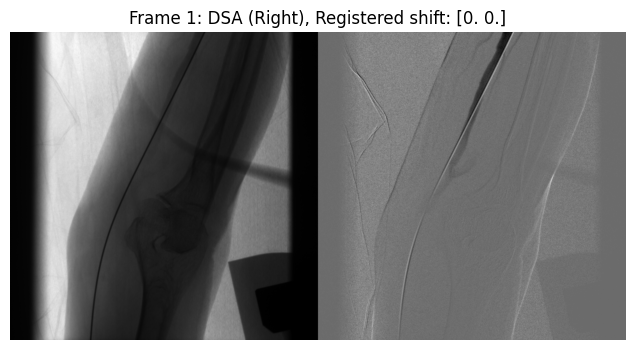

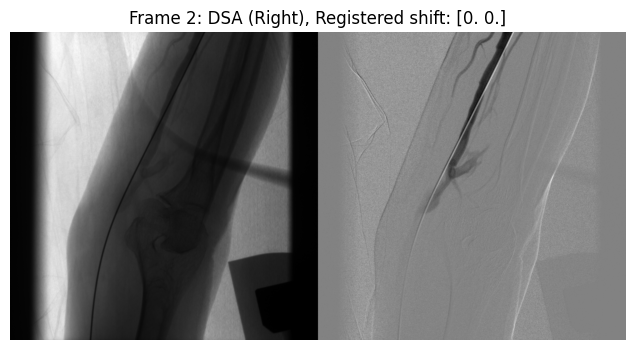

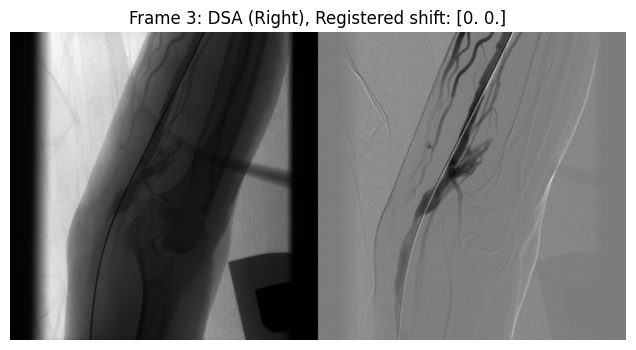

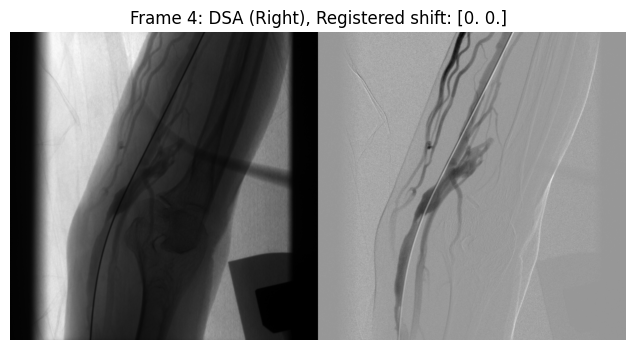

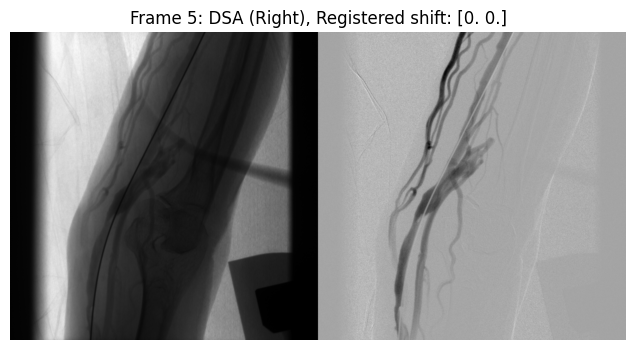

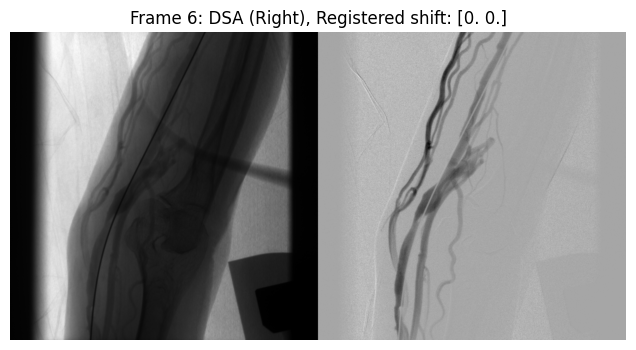

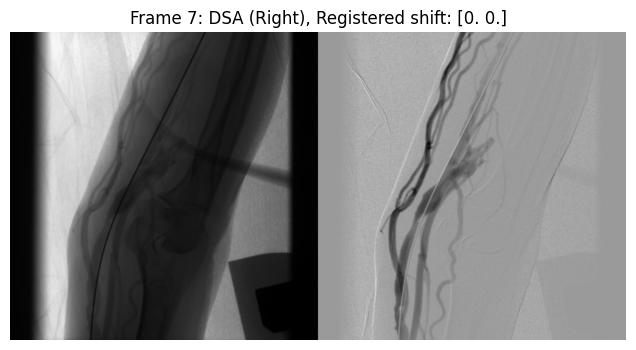

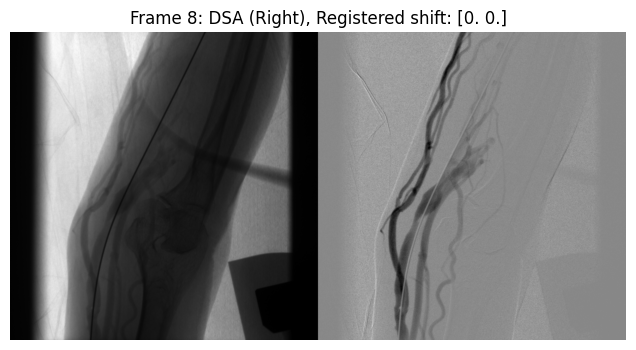

In [ ]:
def normalize_for_display(image, scale=255.0):
    image = image.astype(np.float32)
    image -= np.min(image)
    image /= np.max(image) or 1.0  
    image *= scale
    return image.astype(np.uint8)

def combined_phase_registration(mask_frame, live_frame):
    shift_lp = phase_correlation_log_polar(mask_frame, live_frame)

    # If shift_lp is large, suspect rotation/scale. For now we just log it.
    print(f"Log-polar phase correlation shift (rotation/scale): {shift_lp}")

    # You could use this to adjust, or just fallback to standard shift:
    shifted_live, shift = register_with_phase_correlation(mask_frame, live_frame)
    return shifted_live, shift

def apply_dsa_with_registration(mask_frame, live_frame):
    registered_live, shift = combined_phase_registration(mask_frame, live_frame)
    return apply_dsa(mask_frame, registered_live), shift

def stack_dicom_with_registered_dsa(dicom_frames, start=1, end=5):
    mask_frame = dicom_frames[0]
    comparisons = []

    for i in range(start, min(len(dicom_frames), end + 1)):
        live = dicom_frames[i]
        dsa_16bit, shift = apply_dsa_with_registration(mask_frame, live)

        live_disp = normalize_for_display(live)
        dsa_disp = normalize_for_display(dsa_16bit)

        stacked = np.hstack([live_disp, dsa_disp])
        comparisons.append((stacked, shift))

    return comparisons

def stack_dicom_and_dsa_frames(dicom_frames, start=1, end=5):
    mask_frame = dicom_frames[0]
    comparisons = []

    for i in range(start, min(len(dicom_frames), end + 1)):
        live = dicom_frames[i]
        dsa_16bit = apply_dsa(mask_frame, live)

        live_disp = normalize_for_display(live)
        dsa_disp = normalize_for_display(dsa_16bit)

        stacked = np.hstack([live_disp, dsa_disp])
        comparisons.append(stacked)

    return comparisons


# Display
def display_stacked_results(comparisons):
    for i, (img, shift) in enumerate(comparisons, start=1):
        plt.figure(figsize=(10, 4))
        plt.imshow(img, cmap='gray')
        plt.title(f"Frame {i}: DSA (Right), Registered shift: {shift}")
        plt.axis('off')
        plt.show()

#  Run It
if dicom_frames is not None and len(dicom_frames) > 1:
    comparisons = stack_dicom_with_registered_dsa(dicom_frames, start=8, end=15)
    display_stacked_results(comparisons)
else:
    print("Not enough frames loaded.")
